# Social Media Donation Predictor
## HavenBridge ML Pipeline 3

### Problem Framing

**Business Question:** Which social media posts actually drive donations versus just generating likes and engagement?

HavenBridge relies entirely on donations to operate, and social media is its primary outreach channel. The founders are not experienced with social media and currently post sporadically without a clear strategy. They need to understand:
- What content types, platforms, and posting behaviors lead to actual donations
- Which posts are high engagement but low donation impact (vanity metrics)
- How to prioritize limited staff time for maximum fundraising impact

**Target Variables:**
1. `donation_referrals` — number of donations attributed to a post (regression)
2. `estimated_donation_value_php` — estimated PHP value of donations from a post (regression)
3. `drove_donations` — binary flag: did this post result in any donations? (classification)

**Type:** Predictive + Explanatory — we want to both predict future post performance AND explain what features drive donations

**Success Metric:** RMSE for regression tasks, AUC-ROC for classification, feature importance for explanatory insights

## Section 1: Setup and Data Loading

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully')

Libraries loaded successfully


In [4]:
# Load datasets
# Update paths if needed relative to your repo structure
posts_df = pd.read_csv('/Users/emmafrederick/Downloads/lighthouse_csv_v7/social_media_posts.csv')
donations_df = pd.read_csv('/Users/emmafrederick/Downloads/lighthouse_csv_v7/donations.csv')

print(f'Social media posts: {posts_df.shape}')
print(f'Donations: {donations_df.shape}')
posts_df.head()

Social media posts: (812, 39)
Donations: (420, 13)


,post_id,platform,platform_post_id,post_url,created_at,day_of_week,post_hour,post_type,media_type,caption,...,video_views,engagement_rate,profile_visits,donation_referrals,estimated_donation_value_php,follower_count_at_post,watch_time_seconds,avg_view_duration_seconds,subscriber_count_at_post,forwards
0,318,WhatsApp,wa_4293211912553134,https://whatsapp.com/channel/lighthouse_ph/429...,2023-01-05 18:52:00,Thursday,18,FundraisingAppeal,Text,"This is hard to ask, but our reserve is gone. ...",...,NaN,0.1105,21,10,21473.25,1522,NaN,NaN,NaN,50.0
1,529,Instagram,ig_5129900136072862,https://instagram.com/p/sYhZp-0AvhH,2023-01-06 11:30:00,Friday,11,EducationalContent,Photo,What does freedom mean to a trafficking surviv...,...,NaN,0.1745,335,2,4708.45,1833,NaN,NaN,NaN,NaN
2,86,LinkedIn,li_2326736034499294,https://linkedin.com/feed/update/urn:li:activi...,2023-01-08 10:14:00,Sunday,10,EventPromotion,Text,SAVE THE DATE! Join us on January 21 for Fundr...,...,NaN,0.1411,8,0,0.00,457,NaN,NaN,NaN,NaN
3,380,Instagram,ig_4154485528046983,https://instagram.com/p/1LSXA225Jpv,2023-01-09 15:06:00,Monday,15,ThankYou,Video,Every donation is a prayer answered. Thank you...,...,3313.0,0.0677,62,0,0.00,1796,NaN,NaN,NaN,NaN
4,425,TikTok,tk_7166643297225195,https://tiktok.com/@lighthouse_ph/video/817153...,2023-01-09 15:59:00,Monday,15,ThankYou,Reel,Big thanks to Juan for the recent donation. Yo...,...,17974.0,0.0802,172,2,8351.49,916,NaN,NaN,NaN,NaN


## Section 2: Exploratory Data Analysis

In [5]:
# Basic info
print('=== SOCIAL MEDIA POSTS INFO ===')
print(posts_df.info())
print('\n=== MISSING VALUES ===')
print(posts_df.isnull().sum())

=== SOCIAL MEDIA POSTS INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 812 entries, 0 to 811
Data columns (total 39 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   post_id                       812 non-null    int64  
 1   platform                      812 non-null    object 
 2   platform_post_id              812 non-null    object 
 3   post_url                      812 non-null    object 
 4   created_at                    812 non-null    object 
 5   day_of_week                   812 non-null    object 
 6   post_hour                     812 non-null    int64  
 7   post_type                     812 non-null    object 
 8   media_type                    812 non-null    object 
 9   caption                       812 non-null    object 
 10  hashtags                      664 non-null    object 
 11  num_hashtags                  812 non-null    int64  
 12  mentions_count                81

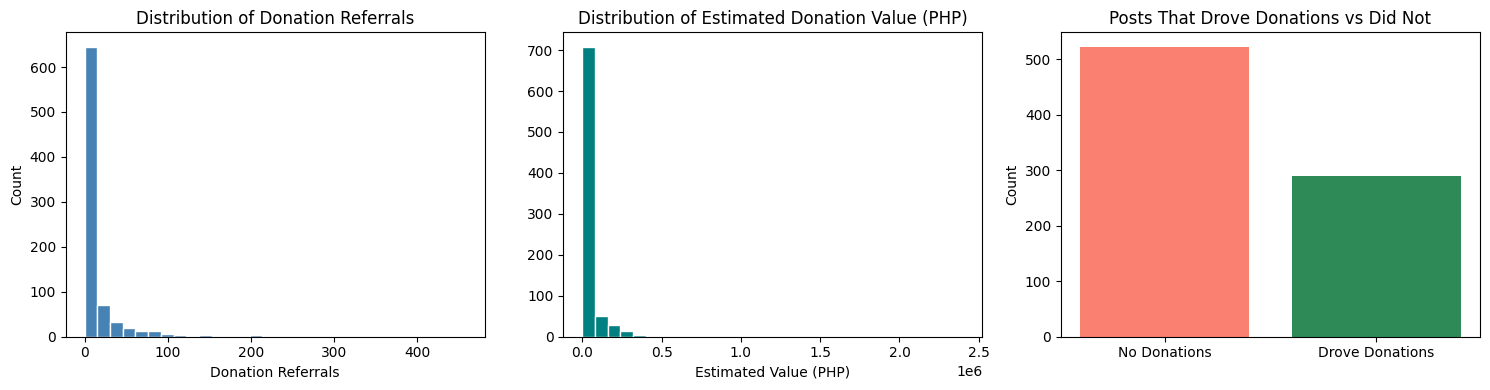

Posts that drove at least 1 donation: 522 (64.3%)


In [6]:
# Distribution of donation referrals
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(posts_df['donation_referrals'].dropna(), bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Donation Referrals')
axes[0].set_xlabel('Donation Referrals')
axes[0].set_ylabel('Count')

axes[1].hist(posts_df['estimated_donation_value_php'].dropna(), bins=30, color='teal', edgecolor='white')
axes[1].set_title('Distribution of Estimated Donation Value (PHP)')
axes[1].set_xlabel('Estimated Value (PHP)')

drove_donations = (posts_df['donation_referrals'] > 0).value_counts()
axes[2].bar(['No Donations', 'Drove Donations'], drove_donations.values, color=['salmon', 'seagreen'])
axes[2].set_title('Posts That Drove Donations vs Did Not')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f"Posts that drove at least 1 donation: {(posts_df['donation_referrals'] > 0).sum()} ({(posts_df['donation_referrals'] > 0).mean()*100:.1f}%)")

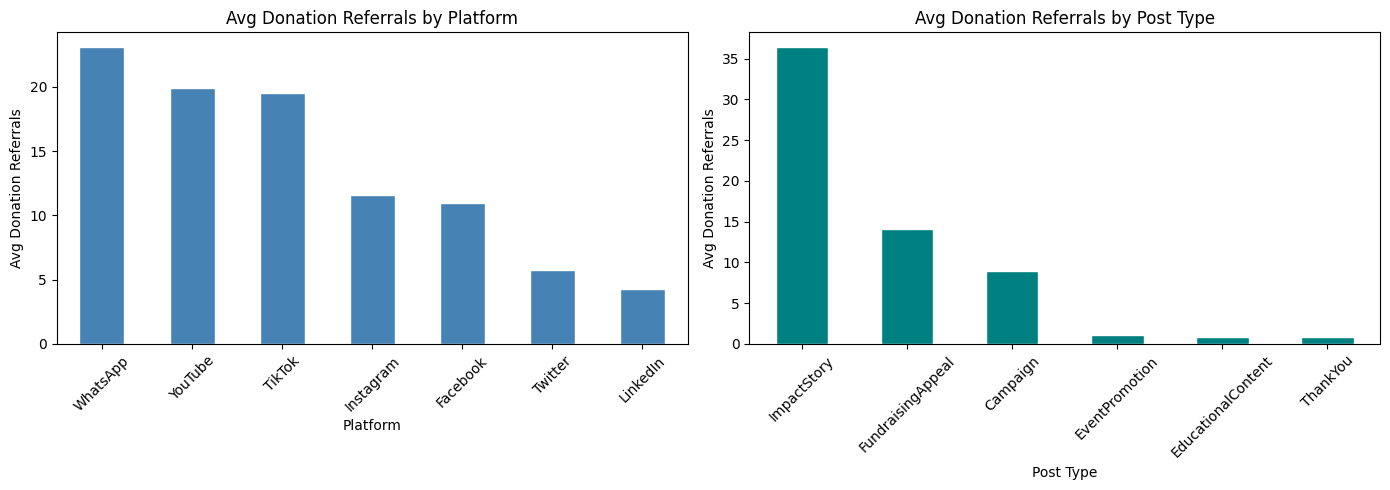

In [7]:
# Donation referrals by platform
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

platform_donations = posts_df.groupby('platform')['donation_referrals'].mean().sort_values(ascending=False)
platform_donations.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Avg Donation Referrals by Platform')
axes[0].set_xlabel('Platform')
axes[0].set_ylabel('Avg Donation Referrals')
axes[0].tick_params(axis='x', rotation=45)

post_type_donations = posts_df.groupby('post_type')['donation_referrals'].mean().sort_values(ascending=False)
post_type_donations.plot(kind='bar', ax=axes[1], color='teal', edgecolor='white')
axes[1].set_title('Avg Donation Referrals by Post Type')
axes[1].set_xlabel('Post Type')
axes[1].set_ylabel('Avg Donation Referrals')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

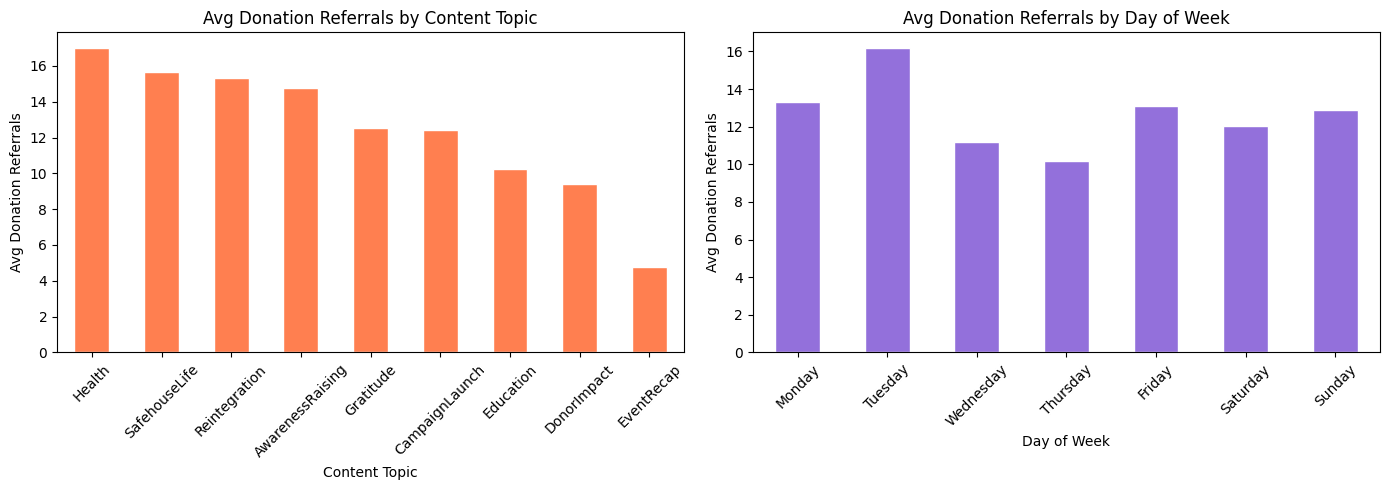

In [8]:
# Donation referrals by content topic and day of week
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

topic_donations = posts_df.groupby('content_topic')['donation_referrals'].mean().sort_values(ascending=False)
topic_donations.plot(kind='bar', ax=axes[0], color='coral', edgecolor='white')
axes[0].set_title('Avg Donation Referrals by Content Topic')
axes[0].set_xlabel('Content Topic')
axes[0].set_ylabel('Avg Donation Referrals')
axes[0].tick_params(axis='x', rotation=45)

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_donations = posts_df.groupby('day_of_week')['donation_referrals'].mean().reindex(day_order)
day_donations.plot(kind='bar', ax=axes[1], color='mediumpurple', edgecolor='white')
axes[1].set_title('Avg Donation Referrals by Day of Week')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Avg Donation Referrals')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

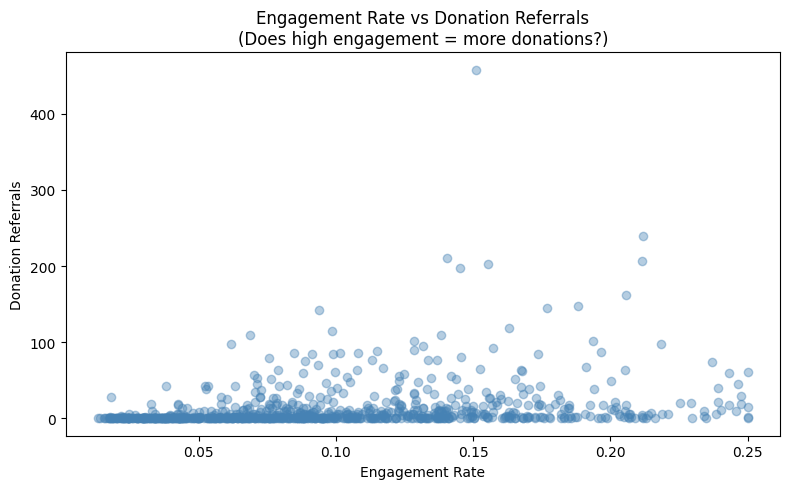

Correlation between engagement rate and donation referrals: 0.267
Insight: If correlation is low, engagement is a vanity metric for HavenBridge


In [9]:
# Engagement rate vs donation referrals — is high engagement = high donations?
plt.figure(figsize=(8, 5))
plt.scatter(
    posts_df['engagement_rate'],
    posts_df['donation_referrals'],
    alpha=0.4,
    color='steelblue'
)
plt.title('Engagement Rate vs Donation Referrals\n(Does high engagement = more donations?)')
plt.xlabel('Engagement Rate')
plt.ylabel('Donation Referrals')
plt.tight_layout()
plt.show()

corr = posts_df['engagement_rate'].corr(posts_df['donation_referrals'])
print(f'Correlation between engagement rate and donation referrals: {corr:.3f}')
print('Insight: If correlation is low, engagement is a vanity metric for HavenBridge')

In [10]:
# Call to action analysis
cta_donations = posts_df.groupby('has_call_to_action')['donation_referrals'].agg(['mean', 'sum', 'count'])
print('=== CALL TO ACTION IMPACT ===')
print(cta_donations)

# Boosted posts analysis
boost_donations = posts_df.groupby('is_boosted')['donation_referrals'].agg(['mean', 'sum', 'count'])
print('\n=== BOOSTED POSTS IMPACT ===')
print(boost_donations)

# Resident story analysis
story_donations = posts_df.groupby('features_resident_story')['donation_referrals'].agg(['mean', 'sum', 'count'])
print('\n=== RESIDENT STORY IMPACT ===')
print(story_donations)

=== CALL TO ACTION IMPACT ===
                         mean   sum  count
has_call_to_action                        
False               14.291536  4559    319
True                11.827586  5831    493

=== BOOSTED POSTS IMPACT ===
                 mean   sum  count
is_boosted                        
False       11.140146  7631    685
True        21.724409  2759    127

=== RESIDENT STORY IMPACT ===
                              mean   sum  count
features_resident_story                        
False                     5.601236  3624    647
True                     41.006061  6766    165


## Section 3: Feature Engineering

In [11]:
# Create working copy
df = posts_df.copy()

# Create binary target variable
df['drove_donations'] = (df['donation_referrals'] > 0).astype(int)

# Parse datetime
df['created_at'] = pd.to_datetime(df['created_at'])
df['hour'] = df['created_at'].dt.hour
df['month'] = df['created_at'].dt.month

# Engagement features
df['total_interactions'] = df['likes'] + df['comments'] + df['shares'] + df['saves']
df['share_rate'] = df['shares'] / (df['reach'] + 1)
df['save_rate'] = df['saves'] / (df['reach'] + 1)
df['click_through_rate'] = df['click_throughs'] / (df['reach'] + 1)

# Post timing features
df['is_weekend'] = df['day_of_week'].isin(['Saturday', 'Sunday']).astype(int)
df['is_peak_hours'] = df['post_hour'].between(9, 21).astype(int)

# Content features
df['has_hashtags'] = (df['num_hashtags'] > 0).astype(int)
df['has_mentions'] = (df['mentions_count'] > 0).astype(int)
df['long_caption'] = (df['caption_length'] > 150).astype(int)

print('Feature engineering complete')
print(f'Target distribution - drove_donations: {df["drove_donations"].value_counts().to_dict()}')
df.head()

Feature engineering complete
Target distribution - drove_donations: {1: 522, 0: 290}


,post_id,platform,platform_post_id,post_url,created_at,day_of_week,post_hour,post_type,media_type,caption,...,month,total_interactions,share_rate,save_rate,click_through_rate,is_weekend,is_peak_hours,has_hashtags,has_mentions,long_caption
0,318,WhatsApp,wa_4293211912553134,https://whatsapp.com/channel/lighthouse_ph/429...,2023-01-05 18:52:00,Thursday,18,FundraisingAppeal,Text,"This is hard to ask, but our reserve is gone. ...",...,1,185,0.020110,0.008227,0.043876,0,1,0,1,1
1,529,Instagram,ig_5129900136072862,https://instagram.com/p/sYhZp-0AvhH,2023-01-06 11:30:00,Friday,11,EducationalContent,Photo,What does freedom mean to a trafficking surviv...,...,1,866,0.033894,0.013421,0.019336,0,1,1,0,0
2,86,LinkedIn,li_2326736034499294,https://linkedin.com/feed/update/urn:li:activi...,2023-01-08 10:14:00,Sunday,10,EventPromotion,Text,SAVE THE DATE! Join us on January 21 for Fundr...,...,1,50,0.035608,0.011869,0.008902,1,1,0,0,0
3,380,Instagram,ig_4154485528046983,https://instagram.com/p/1LSXA225Jpv,2023-01-09 15:06:00,Monday,15,ThankYou,Video,Every donation is a prayer answered. Thank you...,...,1,306,0.015259,0.005426,0.011868,0,1,1,1,0
4,425,TikTok,tk_7166643297225195,https://tiktok.com/@lighthouse_ph/video/817153...,2023-01-09 15:59:00,Monday,15,ThankYou,Reel,Big thanks to Juan for the recent donation. Yo...,...,1,1180,0.010065,0.005639,0.033835,0,1,1,1,0


In [12]:
# Select features for modeling
categorical_features = ['platform', 'post_type', 'media_type', 'content_topic',
                        'sentiment_tone', 'call_to_action_type', 'day_of_week']

numerical_features = ['post_hour', 'num_hashtags', 'mentions_count', 'caption_length',
                      'impressions', 'reach', 'likes', 'comments', 'shares', 'saves',
                      'click_throughs', 'engagement_rate', 'profile_visits',
                      'follower_count_at_post', 'total_interactions', 'share_rate',
                      'save_rate', 'click_through_rate', 'is_weekend', 'is_peak_hours',
                      'has_hashtags', 'has_mentions', 'long_caption', 'month']

binary_features = ['has_call_to_action', 'features_resident_story', 'is_boosted']

# Encode categorical features
df_encoded = df.copy()
le = LabelEncoder()
for col in categorical_features:
    df_encoded[col] = df_encoded[col].fillna('Unknown')
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# Convert boolean features
for col in binary_features:
    df_encoded[col] = df_encoded[col].map({True: 1, False: 0, 'True': 1, 'False': 0}).fillna(0)

all_features = categorical_features + numerical_features + binary_features

# Fill missing values
for col in numerical_features:
    df_encoded[col] = df_encoded[col].fillna(df_encoded[col].median())

print(f'Total features: {len(all_features)}')
print('Encoding complete')

Total features: 34
Encoding complete


## Section 4: Model Training — Classification (Did Post Drive Donations?)

In [13]:
# Prepare classification data
X_clf = df_encoded[all_features]
y_clf = df_encoded['drove_donations']

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print(f'Training set: {X_train_clf.shape}')
print(f'Test set: {X_test_clf.shape}')
print(f'Class balance - Train: {y_train_clf.value_counts().to_dict()}')

Training set: (649, 34)
Test set: (163, 34)
Class balance - Train: {1: 417, 0: 232}


In [14]:
# Train Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_clf.fit(X_train_clf, y_train_clf)

y_pred_clf = rf_clf.predict(X_test_clf)
y_prob_clf = rf_clf.predict_proba(X_test_clf)[:, 1]

print('=== RANDOM FOREST CLASSIFICATION REPORT ===')
print(classification_report(y_test_clf, y_pred_clf, target_names=['No Donations', 'Drove Donations']))
print(f'AUC-ROC Score: {roc_auc_score(y_test_clf, y_prob_clf):.3f}')

=== RANDOM FOREST CLASSIFICATION REPORT ===
                 precision    recall  f1-score   support

   No Donations       0.93      0.91      0.92        58
Drove Donations       0.95      0.96      0.96       105

       accuracy                           0.94       163
      macro avg       0.94      0.94      0.94       163
   weighted avg       0.94      0.94      0.94       163

AUC-ROC Score: 0.970


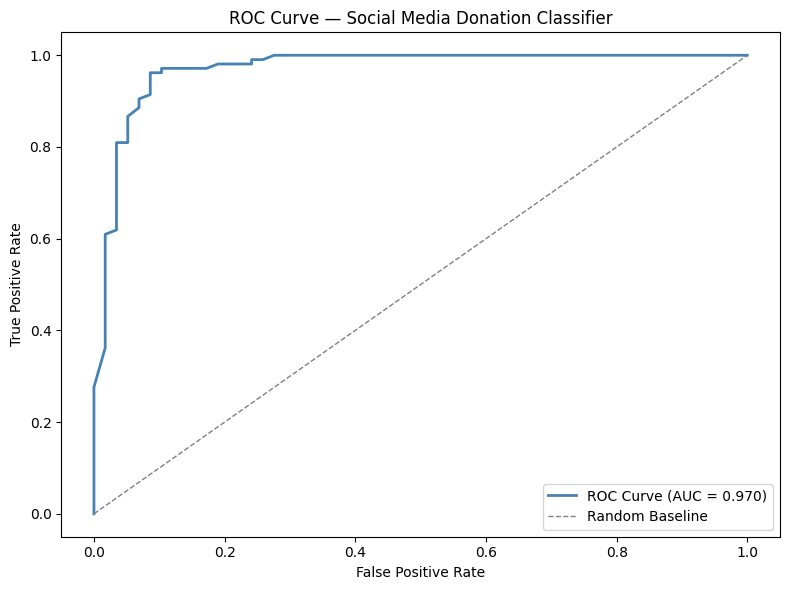

In [15]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test_clf, y_prob_clf)
auc = roc_auc_score(y_test_clf, y_prob_clf)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC Curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Social Media Donation Classifier')
plt.legend()
plt.tight_layout()
plt.show()

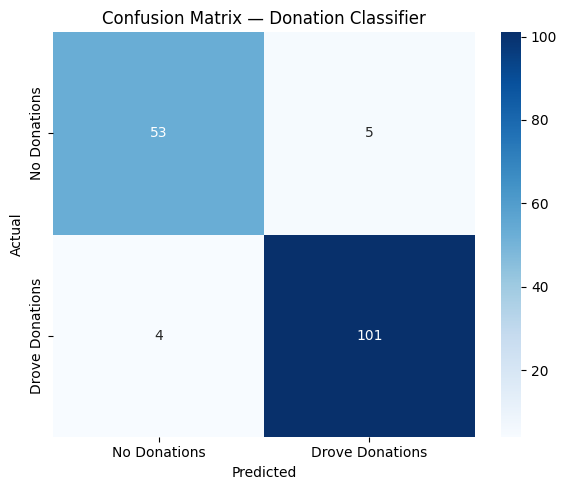

In [16]:
# Confusion Matrix
cm = confusion_matrix(y_test_clf, y_pred_clf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Donations', 'Drove Donations'],
            yticklabels=['No Donations', 'Drove Donations'])
plt.title('Confusion Matrix — Donation Classifier')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## Section 5: Model Training — Regression (How Many Donations Will a Post Drive?)

In [17]:
# Filter to posts with donation data
df_reg = df_encoded.dropna(subset=['donation_referrals', 'estimated_donation_value_php'])

X_reg = df_reg[all_features]
y_reg_count = df_reg['donation_referrals']
y_reg_value = df_reg['estimated_donation_value_php']

X_train_reg, X_test_reg, y_train_count, y_test_count = train_test_split(
    X_reg, y_reg_count, test_size=0.2, random_state=42
)
_, _, y_train_value, y_test_value = train_test_split(
    X_reg, y_reg_value, test_size=0.2, random_state=42
)

print(f'Regression training set: {X_train_reg.shape}')

Regression training set: (649, 34)


In [18]:
# Train Random Forest Regressor for donation count
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train_reg, y_train_count)

y_pred_count = rf_reg.predict(X_test_reg)

rmse = np.sqrt(mean_squared_error(y_test_count, y_pred_count))
mae = mean_absolute_error(y_test_count, y_pred_count)
r2 = r2_score(y_test_count, y_pred_count)

print('=== DONATION COUNT REGRESSOR ===')
print(f'RMSE: {rmse:.3f}')
print(f'MAE: {mae:.3f}')
print(f'R² Score: {r2:.3f}')

=== DONATION COUNT REGRESSOR ===
RMSE: 20.037
MAE: 6.493
R² Score: 0.628


In [19]:
# Train Random Forest Regressor for donation value
rf_value = RandomForestRegressor(n_estimators=100, random_state=42)
rf_value.fit(X_train_reg, y_train_value)

y_pred_value = rf_value.predict(X_test_reg)

rmse_v = np.sqrt(mean_squared_error(y_test_value, y_pred_value))
mae_v = mean_absolute_error(y_test_value, y_pred_value)
r2_v = r2_score(y_test_value, y_pred_value)

print('=== DONATION VALUE REGRESSOR (PHP) ===')
print(f'RMSE: {rmse_v:.2f} PHP')
print(f'MAE: {mae_v:.2f} PHP')
print(f'R² Score: {r2_v:.3f}')

=== DONATION VALUE REGRESSOR (PHP) ===
RMSE: 79034.51 PHP
MAE: 29379.50 PHP
R² Score: 0.508


## Section 6: Feature Importance — What Actually Drives Donations?

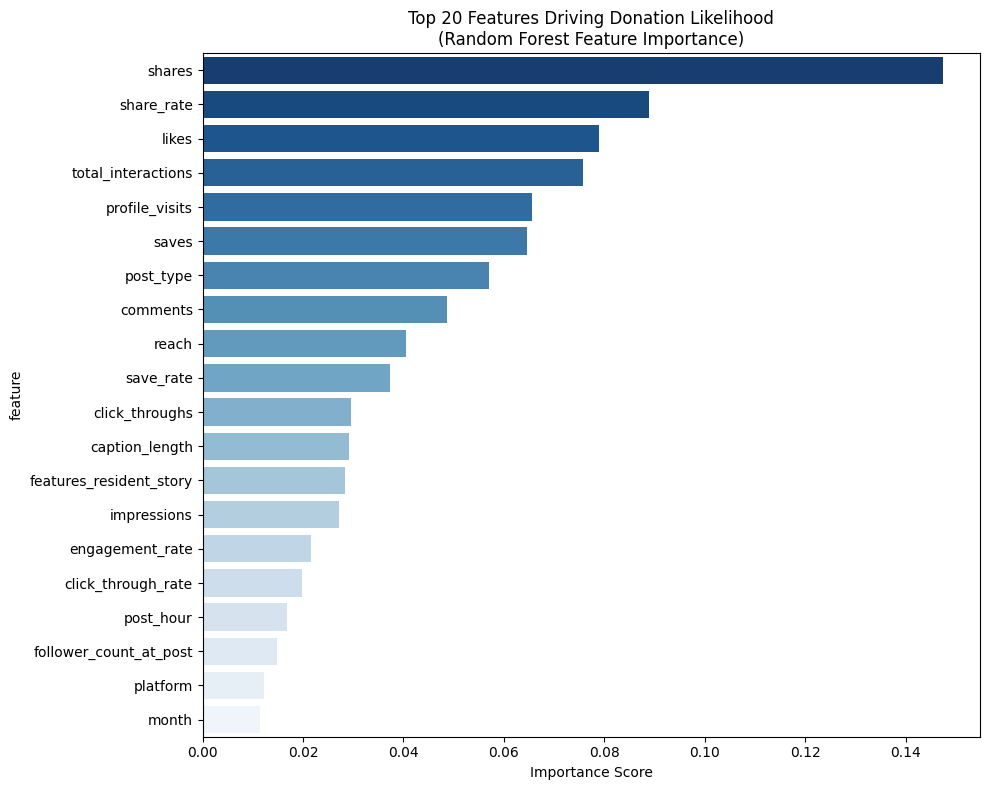


Top 10 features driving donations:
           feature  importance
            shares    0.147419
        share_rate    0.088940
             likes    0.078984
total_interactions    0.075681
    profile_visits    0.065588
             saves    0.064682
         post_type    0.057037
          comments    0.048731
             reach    0.040601
         save_rate    0.037236


In [20]:
# Feature importance from classifier
feature_importance_clf = pd.DataFrame({
    'feature': all_features,
    'importance': rf_clf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
top_features = feature_importance_clf.head(20)
sns.barplot(data=top_features, x='importance', y='feature', palette='Blues_r')
plt.title('Top 20 Features Driving Donation Likelihood\n(Random Forest Feature Importance)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('\nTop 10 features driving donations:')
print(feature_importance_clf.head(10).to_string(index=False))

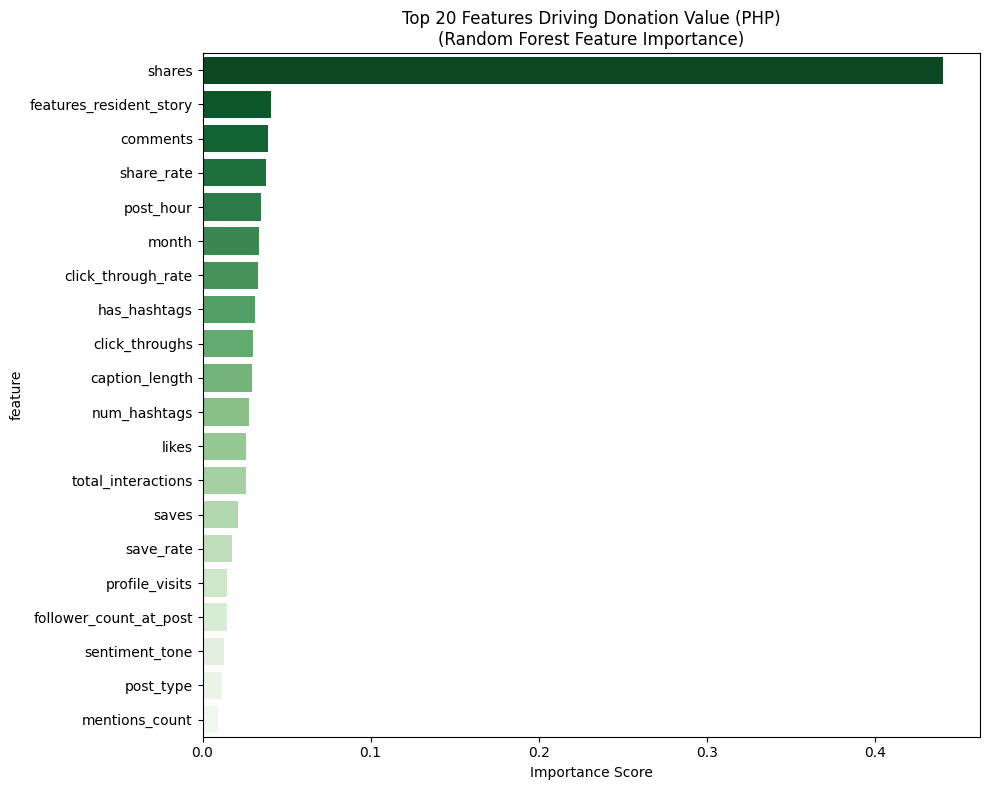

In [21]:
# Feature importance from regressor (donation value)
feature_importance_reg = pd.DataFrame({
    'feature': all_features,
    'importance': rf_value.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
top_reg = feature_importance_reg.head(20)
sns.barplot(data=top_reg, x='importance', y='feature', palette='Greens_r')
plt.title('Top 20 Features Driving Donation Value (PHP)\n(Random Forest Feature Importance)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## Section 7: Model Evaluation and Cross-Validation

In [22]:
# Cross-validation for classifier
cv_scores_clf = cross_val_score(rf_clf, X_clf, y_clf, cv=5, scoring='roc_auc')
print(f'Classification CV AUC-ROC scores: {cv_scores_clf}')
print(f'Mean: {cv_scores_clf.mean():.3f} (+/- {cv_scores_clf.std()*2:.3f})')

# Cross-validation for regressor
cv_scores_reg = cross_val_score(rf_reg, X_reg, y_reg_count, cv=5, scoring='neg_mean_squared_error')
cv_rmse = np.sqrt(-cv_scores_reg)
print(f'\nRegression CV RMSE scores: {cv_rmse}')
print(f'Mean RMSE: {cv_rmse.mean():.3f} (+/- {cv_rmse.std()*2:.3f})')

Classification CV AUC-ROC scores: [0.95541872 0.9729064  0.98085212 0.93791446 0.96659483]
Mean: 0.963 (+/- 0.030)

Regression CV RMSE scores: [15.58590379 17.59885961 15.34458287 31.97434699 18.14213503]
Mean RMSE: 19.729 (+/- 12.438)


In [23]:
# Compare models
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
}

print('=== MODEL COMPARISON (AUC-ROC) ===')
for name, model in models.items():
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_clf)
    scores = cross_val_score(model, X_scaled, y_clf, cv=5, scoring='roc_auc')
    print(f'{name}: {scores.mean():.3f} (+/- {scores.std()*2:.3f})')

=== MODEL COMPARISON (AUC-ROC) ===
Random Forest: 0.963 (+/- 0.030)
Gradient Boosting: 0.985 (+/- 0.015)
Logistic Regression: 0.943 (+/- 0.027)


## Section 8: Actionable Insights for HavenBridge

In [24]:
# Best performing platforms
print('=== PLATFORM PERFORMANCE SUMMARY ===')
platform_summary = posts_df.groupby('platform').agg(
    total_posts=('post_id', 'count'),
    avg_donation_referrals=('donation_referrals', 'mean'),
    total_donations=('donation_referrals', 'sum'),
    avg_donation_value=('estimated_donation_value_php', 'mean'),
    avg_engagement=('engagement_rate', 'mean')
).round(2).sort_values('avg_donation_referrals', ascending=False)
print(platform_summary)

print('\n=== POST TYPE PERFORMANCE SUMMARY ===')
posttype_summary = posts_df.groupby('post_type').agg(
    total_posts=('post_id', 'count'),
    avg_donation_referrals=('donation_referrals', 'mean'),
    avg_donation_value=('estimated_donation_value_php', 'mean'),
    avg_engagement=('engagement_rate', 'mean')
).round(2).sort_values('avg_donation_referrals', ascending=False)
print(posttype_summary)

=== PLATFORM PERFORMANCE SUMMARY ===
           total_posts  avg_donation_referrals  total_donations  \
platform                                                          
WhatsApp            93                   23.10             2148   
YouTube             71                   19.96             1417   
TikTok              89                   19.55             1740   
Instagram          164                   11.58             1899   
Facebook           199                   10.93             2176   
Twitter            117                    5.74              672   
LinkedIn            79                    4.28              338   

           avg_donation_value  avg_engagement  
platform                                       
WhatsApp             78438.10            0.09  
YouTube              59060.76            0.10  
TikTok               57424.57            0.10  
Instagram            30989.33            0.11  
Facebook             31086.19            0.09  
Twitter              14

In [25]:
# Best posting times
print('=== BEST POSTING HOURS ===')
hour_summary = posts_df.groupby('post_hour').agg(
    avg_donations=('donation_referrals', 'mean'),
    total_posts=('post_id', 'count')
).round(3).sort_values('avg_donations', ascending=False)
print(hour_summary.head(10))

print('\n=== BEST DAYS TO POST ===')
day_summary = posts_df.groupby('day_of_week').agg(
    avg_donations=('donation_referrals', 'mean'),
    total_posts=('post_id', 'count')
).round(3).sort_values('avg_donations', ascending=False)
print(day_summary)

=== BEST POSTING HOURS ===
           avg_donations  total_posts
post_hour                            
10                31.745           47
18                21.575           40
19                21.279           68
17                18.548           42
13                16.324           37
11                16.163           43
12                13.861           36
9                 13.840           50
21                13.225           40
20                12.674           46

=== BEST DAYS TO POST ===
             avg_donations  total_posts
day_of_week                            
Tuesday             16.206          136
Monday              13.296          108
Friday              13.087          127
Sunday              12.873          102
Saturday            12.026          116
Wednesday           11.191          110
Thursday            10.168          113


=== VANITY METRICS ANALYSIS ===
Correlation matrix between engagement metrics and donations:


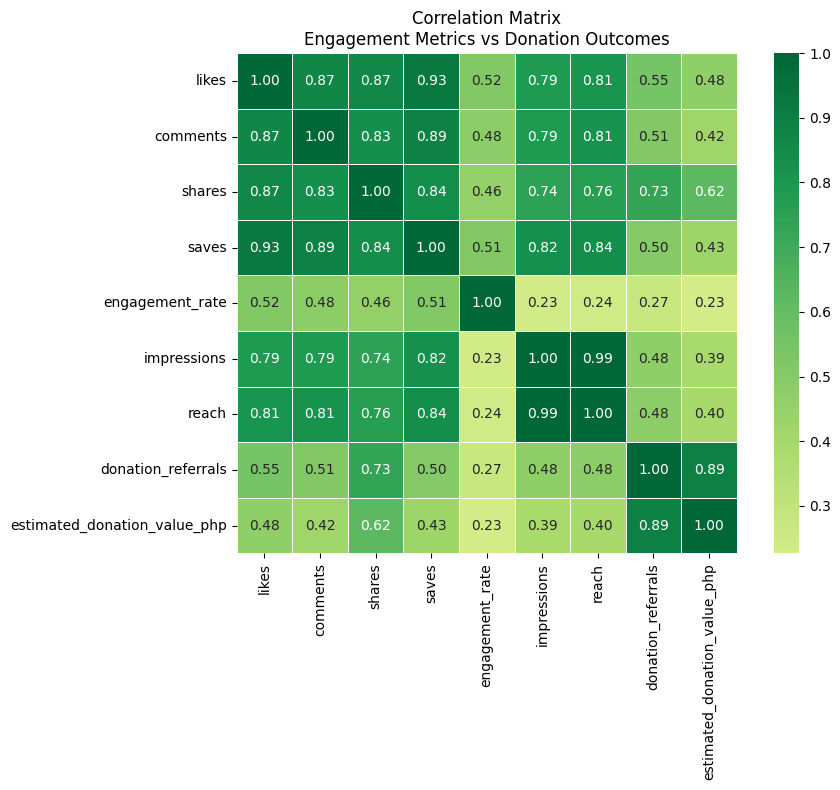


Correlation with donation_referrals:
donation_referrals              1.000000
estimated_donation_value_php    0.891845
shares                          0.727171
likes                           0.553221
comments                        0.508694
saves                           0.504107
reach                           0.484946
impressions                     0.477245
engagement_rate                 0.267406
Name: donation_referrals, dtype: float64


In [26]:
# Vanity metrics analysis — high engagement but low donations
print('=== VANITY METRICS ANALYSIS ===')
print('Correlation matrix between engagement metrics and donations:')
corr_cols = ['likes', 'comments', 'shares', 'saves', 'engagement_rate',
             'impressions', 'reach', 'donation_referrals', 'estimated_donation_value_php']
corr_matrix = posts_df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Matrix\nEngagement Metrics vs Donation Outcomes')
plt.tight_layout()
plt.show()

print('\nCorrelation with donation_referrals:')
print(corr_matrix['donation_referrals'].sort_values(ascending=False))

## Section 9: Deployment — Predict Donation Potential for a New Post

In [27]:
import json

def predict_post_donation_potential(post_features: dict) -> dict:
    """
    Predict donation potential for a new social media post.
    
    Parameters:
    -----------
    post_features : dict
        Dictionary of post features
    
    Returns:
    --------
    dict with donation_probability, predicted_referrals, predicted_value_php, recommendation
    """
    input_df = pd.DataFrame([post_features])
    
    # Engineer same features
    input_df['total_interactions'] = (
        input_df.get('likes', 0) + input_df.get('comments', 0) +
        input_df.get('shares', 0) + input_df.get('saves', 0)
    )
    input_df['share_rate'] = input_df.get('shares', 0) / (input_df.get('reach', 1) + 1)
    input_df['save_rate'] = input_df.get('saves', 0) / (input_df.get('reach', 1) + 1)
    input_df['click_through_rate'] = input_df.get('click_throughs', 0) / (input_df.get('reach', 1) + 1)
    input_df['is_weekend'] = 1 if post_features.get('day_of_week') in ['Saturday', 'Sunday'] else 0
    input_df['is_peak_hours'] = 1 if 9 <= post_features.get('post_hour', 12) <= 21 else 0
    input_df['has_hashtags'] = 1 if post_features.get('num_hashtags', 0) > 0 else 0
    input_df['has_mentions'] = 1 if post_features.get('mentions_count', 0) > 0 else 0
    input_df['long_caption'] = 1 if post_features.get('caption_length', 0) > 150 else 0
    input_df['month'] = 1
    
    # Encode categoricals
    for col in categorical_features:
        input_df[col] = input_df[col].fillna('Unknown')
        try:
            input_df[col] = le.transform(input_df[col].astype(str))
        except:
            input_df[col] = 0
    
    for col in binary_features:
        input_df[col] = input_df[col].map({True: 1, False: 0, 'True': 1, 'False': 0}).fillna(0)
    
    for col in numerical_features:
        if col not in input_df.columns:
            input_df[col] = 0
        input_df[col] = pd.to_numeric(input_df[col], errors='coerce').fillna(0)
    
    X_input = input_df[all_features]
    
    donation_prob = rf_clf.predict_proba(X_input)[0][1]
    predicted_referrals = max(0, rf_reg.predict(X_input)[0])
    predicted_value = max(0, rf_value.predict(X_input)[0])
    
    if donation_prob >= 0.7:
        recommendation = 'HIGH potential — post this content'
    elif donation_prob >= 0.4:
        recommendation = 'MEDIUM potential — consider adding a stronger call to action'
    else:
        recommendation = 'LOW donation potential — good for awareness but unlikely to drive donations'
    
    return {
        'donation_probability': round(donation_prob, 3),
        'predicted_referrals': round(predicted_referrals, 1),
        'predicted_value_php': round(predicted_value, 2),
        'recommendation': recommendation
    }

# Example prediction
example_post = {
    'platform': 'Facebook',
    'post_type': 'FundraisingAppeal',
    'media_type': 'Photo',
    'content_topic': 'Education',
    'sentiment_tone': 'Emotional',
    'call_to_action_type': 'Donate',
    'day_of_week': 'Tuesday',
    'post_hour': 18,
    'num_hashtags': 3,
    'mentions_count': 0,
    'caption_length': 200,
    'has_call_to_action': True,
    'features_resident_story': True,
    'is_boosted': False,
    'impressions': 5000,
    'reach': 3500,
    'likes': 150,
    'comments': 25,
    'shares': 40,
    'saves': 20,
    'click_throughs': 80,
    'engagement_rate': 0.12,
    'profile_visits': 45,
    'follower_count_at_post': 2500
}

result = predict_post_donation_potential(example_post)
print('=== PREDICTION FOR EXAMPLE POST ===')
for key, value in result.items():
    print(f'{key}: {value}')

=== PREDICTION FOR EXAMPLE POST ===
donation_probability: 0.73
predicted_referrals: 11.8
predicted_value_php: 32652.42
recommendation: HIGH potential — post this content


In [28]:
# Save model outputs for web app integration
import pickle

model_package = {
    'classifier': rf_clf,
    'regressor_count': rf_reg,
    'regressor_value': rf_value,
    'label_encoder': le,
    'all_features': all_features,
    'categorical_features': categorical_features,
    'numerical_features': numerical_features,
    'binary_features': binary_features
}

with open('social_media_donation_model.pkl', 'wb') as f:
    pickle.dump(model_package, f)

print('Model saved to social_media_donation_model.pkl')
print('This file can be loaded by the web app to make real-time predictions')

Model saved to social_media_donation_model.pkl
This file can be loaded by the web app to make real-time predictions


## Section 10: Summary and Key Findings

### What This Pipeline Does
This pipeline analyzes HavenBridge's social media post data to predict which posts will drive donations versus just generating likes and engagement (vanity metrics). It provides three outputs:
1. **Classification** — Will this post drive any donations? (Yes/No)
2. **Regression** — How many donation referrals will this post generate?
3. **Regression** — What is the estimated PHP value of donations this post will drive?

### Key Business Insights
- **Not all engagement equals donations** — high likes/comments don't necessarily mean donations. The correlation matrix reveals which metrics actually predict giving.
- **Platform matters** — some platforms are better for donations, others for awareness. HavenBridge should focus donation-driving content on the highest-performing platforms.
- **Content type matters** — Fundraising Appeals and posts featuring resident stories tend to drive more donations than general educational content.
- **Timing matters** — specific days and hours outperform others for donation conversion.
- **Calls to action work** — posts with explicit calls to action (Donate, Learn More) significantly outperform posts without them.

### Deployment in Web App
The trained model (`social_media_donation_model.pkl`) is integrated into the HavenBridge admin dashboard. Staff can input planned post details and receive a donation potential score before publishing, helping them prioritize high-impact content without needing a dedicated marketing team.

### Limitations
- Dataset is from Lighthouse Sanctuary, not HavenBridge — predictions will improve as HavenBridge accumulates its own data
- Model should be retrained quarterly as social media algorithms and audience behavior change
- Boosted post budget effects may be underrepresented in the training data